In [2]:
import numpy as np
import matplotlib.pyplot as plt

## Model

Repressilator:
* $X_1$ represses $X_2$
* $X_2$ represses $X_3$
* $X_3$ represses $X_1$


In [3]:
def propensity(x, params):
    """
    Compute propensities for repressilator.

    x: state vector [X1, X2, X3]
    params: parameter dictionary
    """
    alpha = params["alpha"]
    n     = params["n"]
    gamma = params["gamma"]

    X1, X2, X3 = x

    # Hill repression terms
    a1 = alpha / (1 + X3**n)   # production of X1 (repressed by X3)
    a2 = alpha / (1 + X1**n)   # production of X2
    a3 = alpha / (1 + X2**n)   # production of X3

    # degradation
    a4 = gamma * X1
    a5 = gamma * X2
    a6 = gamma * X3

    return np.array([a1, a2, a3, a4, a5, a6])

def stoichiometry():
    """
    Stoichiometry matrix:
    rows = species [X1, X2, X3]
    columns = reactions
    """
    return np.array([
        [ 1,  0,  0, -1,  0,  0],  # X1
        [ 0,  1,  0,  0, -1,  0],  # X2
        [ 0,  0,  1,  0,  0, -1]   # X3
    ])


## SSA

In [10]:
def gillespie(x0, params, t_max, plot_on=False):
    S = stoichiometry()

    t = 0.0
    x = x0.copy()

    T = [t]
    X = [x.copy()]

    while t < t_max:
        a = propensity(x, params)
        a0 = np.sum(a)

        if a0 <= 0:
            break

        # time step
        r1 = np.random.rand()
        tau = -np.log(r1) / a0
        t += tau

        # reaction selection
        r2 = np.random.rand()
        cumulative = np.cumsum(a) / a0
        j = np.searchsorted(cumulative, r2)

        # update state
        x = x + S[:, j]
        x = np.maximum(x, 0)

        # store
        T.append(t)
        X.append(x.copy())

    T,X = np.array(T), np.array(X)



    if plot_on:
        plt.figure(figsize=(8, 4))

        plt.step(T, X[:, 0], where="post", label="X1")
        plt.step(T, X[:, 1], where="post", label="X2")
        plt.step(T, X[:, 2], where="post", label="X3")

        plt.xlabel("Time")
        plt.ylabel("Molecule count")
        plt.title("Repressilator (SSA)")
        plt.legend()
        plt.grid()

        plt.show()




    return T,X


## Parameters and tests

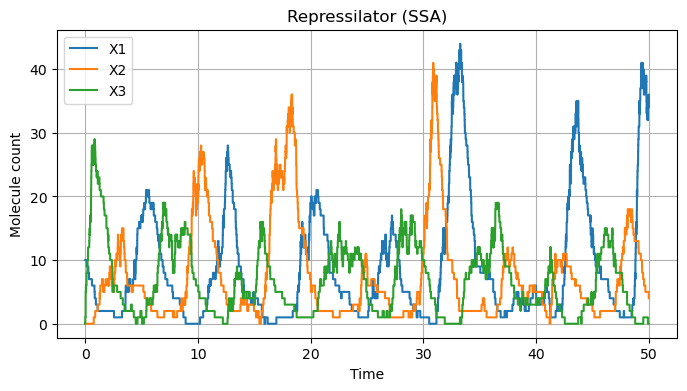

In [14]:
params = {
    "alpha": 50.0,   # production rate
    "n": 2.0,        # Hill coefficient (nonlinearity!)
    "gamma": 1.0     # degradation rate
}

x0 = np.array([10, 0, 0])
t_max = 50

T, X = gillespie(x0, params, t_max, plot_on=True)

## Multiple runs

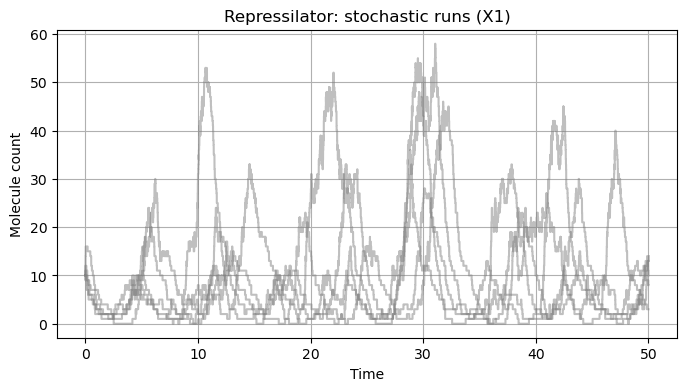

In [18]:
plt.figure(figsize=(8, 4))

for i in range(5):
    T, X = gillespie(x0, params, t_max)
    plt.step(T, X[:, 0], where="post", alpha=0.5, color="grey")

plt.title("Repressilator: stochastic runs (X1)")
plt.xlabel("Time")
plt.ylabel("Molecule count")
plt.grid()
plt.show()